# Validation check for P1 and P5 sample simulation

We here test the L1 pipeline data products for the P1 and P5 sample. The production of the following data was done using the corresponding input catalogues and the PLATOnium executions:

- platonium 500 1 1 23 --project L1-pipeline --seed 1234 --sample P1
- platonium 500 1 1 23 --project L1-pipeline --seed 1234 --sample P5

This, we test with star ID 500, N-CAM 1.1 and Q23. We here secure that the seeds are fixed in the random number generator, so we can reproduce the results.

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [2]:
# Second part libraries
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# PlatoSim libraries
from platosim.simfile import SimFile
from platosim.plot import plotPhotometry
from platosim.utilities import errorcode, normalize
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()
#from platosim.statistics import sortlc, plot_modelfit, plot_residuals, plot_standardized_residuals

# import warnings
# warnings.simplefilter("ignore")

## Create input misalignment models

In [3]:
# Choose directory to save and unpack data
idir = '/lhome/nicholas/software/workdir/jitterImpact/input/'

# Constants
ppmh = 144   # For a cadence of 25s
model = 'y ~ x'
ms, aa = 3, 0.1

In [10]:
def matrixMisalignment(x, y, z):   
    r11 = + np.cos(x)*np.cos(z) - np.sin(x)*np.sin(z)*np.sin(y)
    r12 = - np.cos(x)*np.sin(z) - np.sin(x)*np.cos(z)*np.cos(y)
    r13 = + np.sin(x)*np.sin(z)
    r21 = + np.sin(x)*np.cos(z) + np.cos(x)*np.sin(z)*np.cos(y)
    r22 = - np.sin(x)*np.sin(z) - np.cos(x)*np.cos(z)*np.cos(y)
    r23 = - np.cos(x)*np.sin(z)
    r31 = + np.sin(z)*np.sin(y)
    r32 = + np.cos(z)*np.sin(y)
    r33 = - np.cos(y)   
    R = np.array([[r11, r12, r13],
                  [r21, r22, r23],
                  [r31, r32, r33]])
    return R


def changeOfPointing(x, y, z, phi, theta):
    R = np.array([[ 0, -z,  y],
                  [ z,  0, -x],
                  [-y,  x,  0]])
    A = np.array([[np.cos(phi)*np.sin(theta)],
                  [np.sin(phi)*np.sin(theta)], 
                  [1]])
    return np.dot(R,A).T

In [11]:
# Perfect pointing to provisional SPF (ICRS - equatorial)
ra  = 86.79870508
dec = -46.39594703
rot = -4.0
ICRS = np.array([ra, dec, rot])
quarters = np.array([1, 2, 3, 4, 5, 6, 7, 8])
sigma = 3

### Generate PRE file

In [13]:
# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 3.0/3600
b = 6.0/3600

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(len(quarters))])
bb = np.array([np.random.normal(0, b/sigma) for i in range(len(quarters))])

# Corresponding yaw, pitch, roll
y = tt
z = 3 * y
x = bb - z

# ICRS pointing angles
phi   = np.deg2rad(ra)
theta = np.deg2rad(dec)

# Find change to pointing for quarters
coor = np.zeros((len(quarters), 4))
for i in range(len(quarters)):
    data = changeOfPointing(x[i], y[i], z[i], phi, theta)[0]
    coor[i,:] = np.append(quarters[i], data)

# Save file with relative pointing errors [deg]
np.savetxt(f'{inputDir}/PRE.txt', coor, fmt=['%i', '%0.8f', '%0.8f', '%0.8f'])

print('Yaw, Pitch, and Roll angles')
print(x)
print(y)
print(z)

print('\nChange of coordinates [arcsec]')
print(coor*3600)

print('\nNew coordinates [deg]')
for i in range(len(quarters)):
    print(coor[i][1]+ra, coor[i][2]+dec, coor[i][3])

Yaw, Pitch, and Roll angles
[-0.00110172 -0.00172198  0.00177424 -0.00156901  0.00028999 -0.00056485
 -0.000381    0.00023698]
[ 2.12496225e-04  2.94838183e-04 -4.69853371e-04  3.46688587e-04
 -4.77775876e-05 -1.86640671e-04  1.16406353e-04 -6.24567691e-06]
[ 6.37488674e-04  8.84514550e-04 -1.40956011e-03  1.04006576e-03
 -1.43332763e-04 -5.59922012e-04  3.49219060e-04 -1.87370307e-05]

Change of coordinates [arcsec]
[[ 3.60000000e+03  2.42422606e+00  3.87337681e+00  2.89845546e+00]
 [ 7.20000000e+03  3.36360991e+00  6.07036553e+00  4.52484989e+00]
 [ 1.08000000e+04 -5.36024011e+00 -6.18206468e+00 -4.68634730e+00]
 [ 1.44000000e+04  3.95513619e+00  5.49703387e+00  4.13425520e+00]
 [ 1.80000000e+04 -5.45062262e-01 -1.02311588e+00 -7.61746927e-01]
 [ 2.16000000e+04 -2.12925749e+00  2.11496000e+00  1.44299859e+00]
 [ 2.52000000e+04  1.32800155e+00  1.32077513e+00  1.00861299e+00]
 [ 2.88000000e+04 -7.12527141e-02 -8.50393900e-01 -6.17710225e-01]]

New coordinates [deg]
86.7993784761281 -4

### Generate APE file

In [3]:
# # Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
# t = 4.5/60  # [deg]
# b = 9.0/60  # [deg]

# # Find distribution within 3 sigma of req.
# tt = np.array([np.random.normal(0, t/sigma) for i in range(24)])
# bb = np.array([np.random.normal(0, b/sigma) for i in range(24)])

# # Corresponding yaw, pitch, roll
# dy = tt
# dz = 3 * dy
# dx = bb - dz
# mu, sigma = 0, xreq/sigma # mean and standard deviation
# s = np.random.normal(mu, sigma, 1000)
# count, bins, ignored = plt.hist(s, 30, density=True)
# plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * 
#          np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
#          linewidth=2, color='r')
# plt.show()

# # Save APE camera misalignments
# out = np.transpose([tt, bb])
# np.savetxt('APE.txt', out, fmt='%.8f')

# print('Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]')
# print(np.transpose([tt, bb, dx, dy, dz])*60)

## Correct pandas columns

In [ ]:
# User parameters
idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1"
odir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1_corrected"
# Correct columns
phot = LightCurve(idir, mode="multi")
phot.correct_and_save(idir, odir, numBegin=724, numEnd=1000)

  1%|▌                                                 | 3/277 [57:18<87:33:22, 1150.37s/it]         

## Download and plot light curve

In [189]:
idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1_corrected/000000006"
phot = LightCurve(idir, mode="multi")

In [190]:
phot.unpack()

In [191]:
# Fetch the first file
filenames = phot.files("ftr")
filenames[0]

'/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1_corrected/000000006/000000006_Ncam1.4_Q23.ftr'

In [192]:
# Fetch light curve
lc = LightCurve(filenames[1])
lc.data().head()

,index,time,flux,cx,cy,bg,flux_err,cx_err,cy_err,bg_err,chi2,iter,lamb
0,0,1.788480e+08,426513.351903,2.878858,2.520876,1760.927922,709.180332,0.001009,0.001210,13.328112,10.855872,5,0.370370
1,1,1.788480e+08,427846.548171,2.879140,2.522030,1734.911783,709.919238,0.001007,0.001209,13.292727,10.071918,6,0.123457
2,2,1.788481e+08,426155.030421,2.877784,2.520695,1732.744245,708.710763,0.001007,0.001213,13.289749,11.053297,6,0.123457
3,3,1.788481e+08,428582.445096,2.881126,2.517088,1710.875772,710.357871,0.001004,0.001204,13.264358,10.070380,7,0.041152
4,4,1.788481e+08,427601.984358,2.882461,2.520355,1723.957937,709.775734,0.001005,0.001208,13.282568,9.621197,6,0.123457


In [193]:
# Get target star information
star = lc.star_info(phot.files("cat")[0])
print(f"""
Pmag : {star[0]}
rOA  : {star[1]}
rCOB : {star[2]}
nCon : {star[3]}
rCon : {star[4]}
dMag : {star[5]}
SPR  : {star[6]}
""")


Pmag : 9.83
rOA  : 16.66739045819196
rCOB : 0.4980599075914642
nCon : 3
rCon : 4.340207139976348
dMag : 2.25
SPR  : 0.5702170414994816



In [194]:
# Get noise-less light curve
lc.varsource()

,time,spot,gran,puls,tran,sum
0,171072000.0,-270.189796,-31.192465,22.197519,0.0,-279.184742
1,171072025.0,-270.262380,-33.601544,15.938269,0.0,-287.925655
2,171072050.0,-270.332711,-36.351999,8.970701,0.0,-297.714009
3,171072075.0,-270.400820,-38.999871,1.758188,0.0,-307.642504
4,171072100.0,-270.466740,-38.626356,-5.172246,0.0,-314.265342
...,...,...,...,...,...,...
622075,186623875.0,-226.211057,-51.268362,7.304518,0.0,-270.174902
622076,186623900.0,-226.070401,-47.593172,4.896383,0.0,-268.767190
622077,186623925.0,-225.929202,-41.729126,2.286335,0.0,-265.371994
622078,186623950.0,-225.787457,-34.215206,-0.299831,0.0,-260.302494


<IPython.core.display.Javascript object>


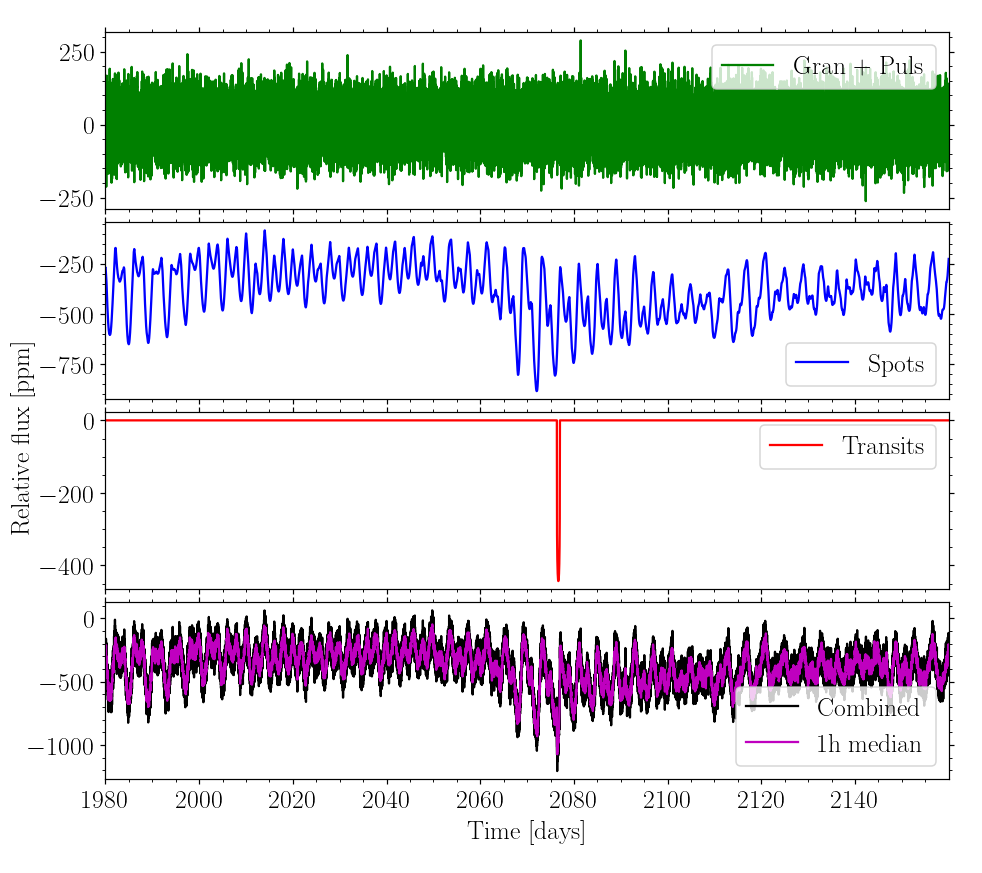

In [195]:
# Plot the input noise-less light curve
lc.plot_varsource(figsize=(9,8));

<IPython.core.display.Javascript object>


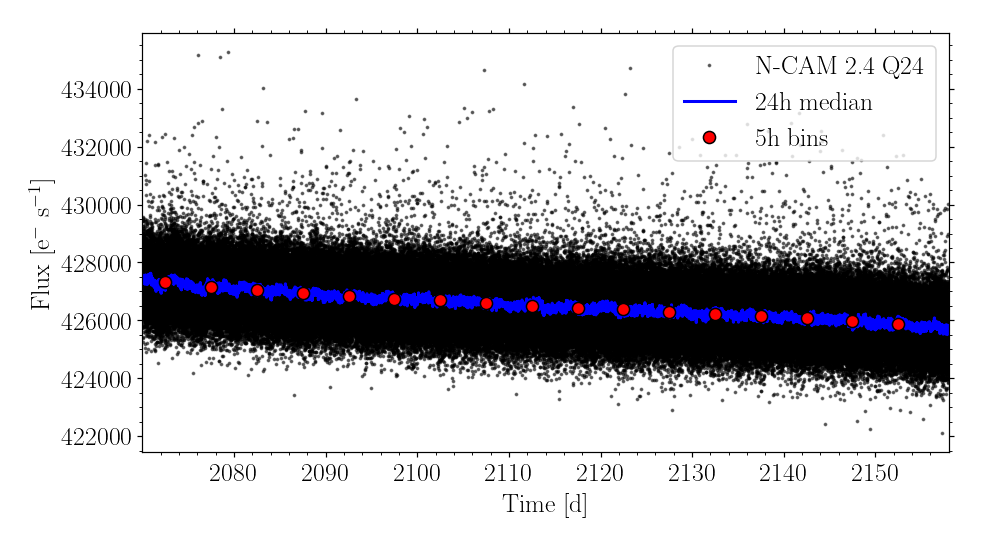

In [196]:
fig, ax = lc.plot(time_unit="d", binsize=5, median_filter=24, figsize=(9,5));
# fig.savefig('camera_JitterNone_Star1.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


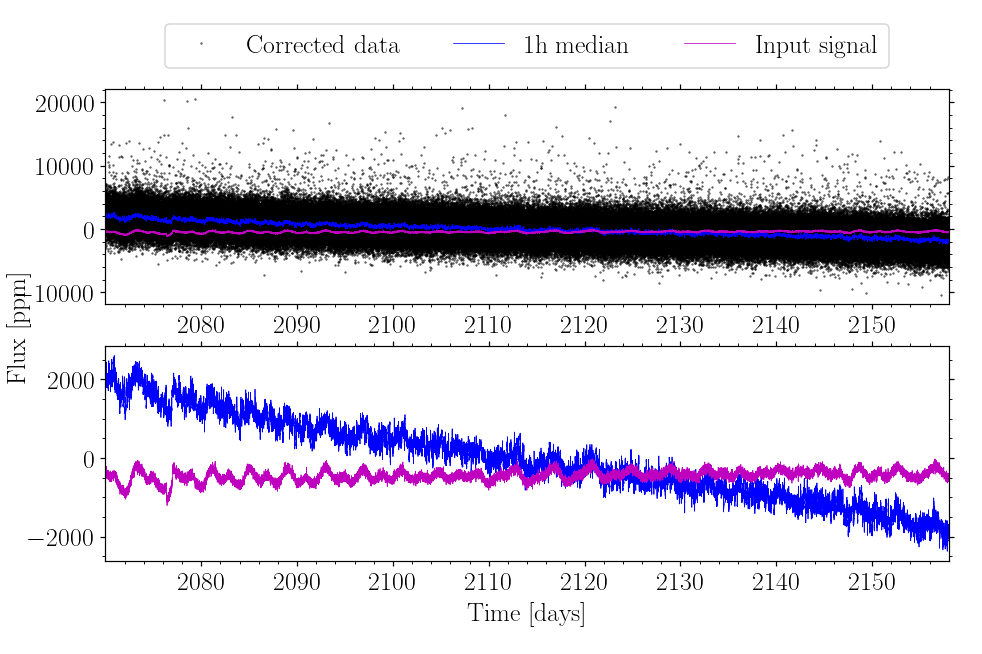

In [197]:
lc.plot_oc();